# 06 - Auditoria: analisis de contrafactuales

**Objetivo:** Generar contrafactuales para varios ejemplos de clase real 0 y 1 en ambos
escenarios de coste, para poder explicarle a un cliente por que se le deniega un credito y
que cambios harian variar la decision.

**Entregable(s) que produce este notebook:**
- `results/tables/contrafactuals_ejemplos.csv`
- `results/figures/contrafactuals_*.png`

## Conectores

**Que recibe de los notebooks anteriores:**
- `results/models/modelo_coste1.joblib` (de `03_modelo_coste1.ipynb`)
- `results/models/modelo_coste10.joblib` (de `04_modelo_coste10.ipynb`)
- `data/processed/test.parquet` (de `02_preprocesado.ipynb`)
- `results/predicciones/cs_produccion1.csv` (de `03_modelo_coste1.ipynb`) y
  `results/predicciones/cs_produccion2.csv` (de `04_modelo_coste10.ipynb`), para localizar
  casos denegados reales en cada escenario de coste

**Que entrega a los notebooks siguientes:**
- Tabla de contrafactuales (`results/tables/contrafactuals_ejemplos.csv`)

consumida por `99_ENTREGA.ipynb` (seccion de auditoria y explicaciones al cliente).

## Decisiones que afectan a este notebook

- **D-0.1** (modelo supervisado vs Multiarmed Bandit): **CERRADA** en `docs/DECISIONES.md` a
  favor de un **modelo supervisado** (XGBoost). Al ser un clasificador entrenado offline que
  expone `predict_proba`, la generacion de contrafactuales (buscar la instancia mas proxima con
  prediccion opuesta, ver `docs/teoria/contrafactuals.md` seccion 2.2) puede optimizar
  directamente sobre esa funcion de score estatica, sin las complicaciones que habria tenido un
  bandit.
- **Escenario 2 asimetrico** (D-3.2, CERRADA): el "10" del escenario 2 es una **errata
  confirmada por el profesor**; el coste es asimetrico C_FN = 10*C_FP, con umbral de decision
  0.0906 (frente a 0.4934 del escenario 1). Los casos denegados que se localizan en
  `cs_produccion2.csv` corresponden a ese umbral asimetrico.
- **Propuesta D-6.1** (herramienta a usar para generar los contrafactuales): pendiente de fijar.
  `docs/teoria/contrafactuals.md` (seccion 2.4) confirma que el material teorico del taller no
  menciona ninguna libreria concreta (ni DiCE ni otra) para generar contrafactuales, por lo que
  la eleccion de herramienta (p. ej. DiCE, o una busqueda/optimizacion propia sobre variables
  accionables) es una decision de implementacion del grupo, no una instruccion del material.
- **Propuesta D-6.2** (numero de ejemplos por clase real y por escenario de coste a analizar):
  pendiente de fijar. El enunciado (`taller_XAI.pdf`, ver `docs/teoria/contrafactuals.md`
  seccion 3.1) pide 'varios ejemplos de clase real 0 y 1', sin fijar una cantidad exacta; queda
  para este notebook decidir cuantos casos por clase y por escenario (coste1 / coste10) se
  analizan.
- Nota adicional (`docs/teoria/contrafactuals.md`, seccion 3.2): conviene distinguir, para las
  variables del dataset, entre variables potencialmente accionables (p. ej.
  `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, `NumberOfOpenCreditLinesAndLoans`,
  `MonthlyIncome`) y variables no accionables o de hechos pasados (p. ej. `age`, los contadores
  de retrasos de pago, `NumberOfDependents`), para que el contrafactual resultante sea una
  explicacion razonable de cara al cliente.
- Nota adicional (`docs/teoria/contrafactuals.md`, seccion 3.3): para clase real 0 denegada
  (falso positivo) el contrafactual es directamente explicativo de cara al cliente; para clase
  real 1 correctamente denegada, tiene mas valor como auditoria interna del modelo que como
  explicacion literal a comunicar.

## 1. Seleccion de ejemplos de clase real 0 y clase real 1 (ambos escenarios de coste)

Localizar, cruzando `data/processed/test.parquet` (que incluye el target real) con los
casos denegados de `results/predicciones/cs_produccion1.csv` y
`results/predicciones/cs_produccion2.csv`, varios ejemplos de clase real 0 y de clase real 1
para cada escenario de coste (coste1 y coste10), segun el numero fijado en la propuesta D-6.2.

In [1]:
# === Configuracion comun para la seleccion de casos ===
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import cost_utils as cu

TARGET = "SeriousDlqin2yrs"
N_EJEMPLOS_POR_CLASE = 2

test = pd.read_parquet(ROOT / "data" / "processed" / "test.parquet")
X_test = test.drop(columns=[TARGET])
y_test = test[TARGET].astype(int)

pipeline = joblib.load(ROOT / "results" / "models" / "preprocessing_pipeline.joblib")
X_test_original = pipeline.inverse_transform(X_test)

def predicciones_escenario(bundle, escenario):
    features = list(bundle["features"])
    proba = bundle["modelo"].predict_proba(X_test.loc[:, features])[:, 1]
    pred = cu.aplicar_umbral(proba, bundle["umbral"])

    return pd.DataFrame({
        "id_test": X_test.index.to_numpy(),
        "escenario": escenario,
        "clase_real": y_test.to_numpy(),
        "proba_impago": proba,
        "umbral": float(bundle["umbral"]),
        "decision_modelo": pred,  # 1 = denegar, 0 = conceder
    })

def resumen_decisiones(df):
    return (
        df.assign(decision=np.where(df["decision_modelo"].eq(1), "denegar", "conceder"))
        .groupby(["escenario", "clase_real", "decision"], as_index=False)
        .size()
        .rename(columns={"size": "n_casos_test"})
    )

def seleccionar_denegados(df_escenario: pd.DataFrame, clase_real: int, n: int = 2):
    candidatos = df_escenario[
        (df_escenario["clase_real"].eq(clase_real))
        & (df_escenario["decision_modelo"].eq(1))
    ].copy()

    if candidatos.empty:
        raise ValueError(
            f"No hay denegados en {df_escenario['escenario'].iloc[0]} "
            f"con clase real {clase_real}."
        )

    candidatos["distancia_umbral"] = (
        candidatos["proba_impago"] - candidatos["umbral"]
    ).abs()

    borde = candidatos.sort_values(["distancia_umbral", "id_test"]).iloc[0]

    resto = candidatos.drop(index=borde.name)
    if resto.empty:
        resto = candidatos

    fuerte = resto.sort_values(
        ["proba_impago", "id_test"],
        ascending=[False, True],
    ).iloc[0]

    seleccion = [
        {**borde.to_dict(), "tipo_caso": "borde_umbral"},
        {**fuerte.to_dict(), "tipo_caso": "denegacion_fuerte"},
    ]

    return seleccion[:n]

def preparar_tabla_casos(casos_meta):
    casos_meta = pd.DataFrame(casos_meta).reset_index(drop=True)
    casos_meta["margen_sobre_umbral"] = (
        casos_meta["proba_impago"] - casos_meta["umbral"]
    )

    features_originales = (
        X_test_original
        .loc[casos_meta["id_test"]]
        .reset_index(drop=True)
    )

    casos = pd.concat(
        [casos_meta.reset_index(drop=True), features_originales],
        axis=1,
    )

    columnas_enteras = [
        "id_test",
        "clase_real",
        "decision_modelo",
        "age",
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfOpenCreditLinesAndLoans",
        "NumberRealEstateLoansOrLines",
        "NumberOfDependents",
        "is_missing_monthlyincome",
        "es_centinela_pastdue",
    ]

    for col in columnas_enteras:
        if col in casos.columns:
            casos[col] = casos[col].round().astype(int)

    return casos.round({
        "proba_impago": 6,
        "umbral": 6,
        "distancia_umbral": 6,
        "margen_sobre_umbral": 6,
        "RevolvingUtilizationOfUnsecuredLines": 4,
        "DebtRatio": 4,
        "MonthlyIncome": 2,
    })

In [2]:
# TODO: 1. Seleccion de ejemplos de clase real 0 y clase real 1 (coste 1)

bundle_coste1 = joblib.load(ROOT / "results" / "models" / "modelo_coste1.joblib")
pred_coste1 = predicciones_escenario(bundle_coste1, "coste1")

resumen_coste1 = resumen_decisiones(pred_coste1)

filas_coste1 = []
for clase_real in [0, 1]:
    filas_coste1.extend(
        seleccionar_denegados(
            df_escenario=pred_coste1,
            clase_real=clase_real,
            n=N_EJEMPLOS_POR_CLASE,
        )
    )

casos_coste1 = preparar_tabla_casos(filas_coste1)

print("Resumen escenario coste1")
display(resumen_coste1)

print("Casos seleccionados escenario coste1")
display(casos_coste1)

Resumen escenario coste1


,escenario,clase_real,decision,n_casos_test
0,coste1,0,conceder,19383
1,coste1,0,denegar,213
2,coste1,1,conceder,1118
3,coste1,1,denegar,286


Casos seleccionados escenario coste1


,id_test,escenario,clase_real,proba_impago,umbral,decision_modelo,distancia_umbral,tipo_caso,margen_sobre_umbral,RevolvingUtilizationOfUnsecuredLines,...,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,is_missing_monthlyincome,es_centinela_pastdue
0,52346,coste1,0,0.493506,0.493394,1,0.000111,borde_umbral,0.000111,1.1029,...,2,0.0832,4720.0,5,0,1,0,3,0,0
1,28495,coste1,0,0.833349,0.493394,1,0.339955,denegacion_fuerte,0.339955,0.9965,...,4,0.7511,5907.5,18,3,0,4,0,1,0
2,10358,coste1,1,0.493573,0.493394,1,0.000179,borde_umbral,0.000179,1.1029,...,4,0.2583,2697.0,15,0,0,0,0,0,0
3,79585,coste1,1,0.916853,0.493394,1,0.423459,denegacion_fuerte,0.423459,1.0434,...,5,0.5835,2794.0,16,5,0,5,0,0,0


In [3]:

# TODO: 1. Seleccion de ejemplos de clase real 0 y clase real 1 (coste 10)

bundle_coste10 = joblib.load(ROOT / "results" / "models" / "modelo_coste10.joblib")
pred_coste10 = predicciones_escenario(bundle_coste10, "coste10")

resumen_coste10 = resumen_decisiones(pred_coste10)

filas_coste10 = []
for clase_real in [0, 1]:
    filas_coste10.extend(
        seleccionar_denegados(
            df_escenario=pred_coste10,
            clase_real=clase_real,
            n=N_EJEMPLOS_POR_CLASE,
        )
    )

casos_coste10 = preparar_tabla_casos(filas_coste10)

print("Resumen escenario coste10")
display(resumen_coste10)

print("Casos seleccionados escenario coste10")
display(casos_coste10)

Resumen escenario coste10


,escenario,clase_real,decision,n_casos_test
0,coste10,0,conceder,16678
1,coste10,0,denegar,2918
2,coste10,1,conceder,396
3,coste10,1,denegar,1008


Casos seleccionados escenario coste10


,id_test,escenario,clase_real,proba_impago,umbral,decision_modelo,distancia_umbral,tipo_caso,margen_sobre_umbral,RevolvingUtilizationOfUnsecuredLines,...,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,is_missing_monthlyincome,es_centinela_pastdue
0,19744,coste10,0,0.090614,0.090609,1,0.000005,borde_umbral,0.000005,1.0000,...,0,0.5257,2200.0,4,0,1,0,1,0,0
1,28495,coste10,0,0.833349,0.090609,1,0.742740,denegacion_fuerte,0.742740,0.9965,...,4,0.7511,5907.5,18,3,0,4,0,1,0
2,14183,coste10,1,0.090845,0.090609,1,0.000236,borde_umbral,0.000236,0.0666,...,0,1.2834,800.0,12,1,1,0,0,0,0
3,79585,coste10,1,0.916853,0.090609,1,0.826244,denegacion_fuerte,0.826244,1.0434,...,5,0.5835,2794.0,16,5,0,5,0,0,0


## 2. Generacion de contrafactuales

Generar, para cada ejemplo seleccionado en la seccion 1, un contrafactual (instancia hipotetica
proxima con prediccion opuesta) usando la herramienta que se fije en la propuesta D-6.1,
respetando la distincion entre variables accionables e inmutables descrita en
`docs/teoria/contrafactuals.md` (seccion 3.2).

In [14]:
# 2. Generacion de contrafactuales con DiCE (propuesta D-6.1)

import dice_ml
from raiutils.exceptions import UserConfigValidationException

# ---------------------------------------------------------------------
# Restricciones de accionabilidad
# ---------------------------------------------------------------------

FEATURES_ACCIONABLES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
]
FEATURES_REDUCIBLES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "NumberOfOpenCreditLinesAndLoans",
]
FEATURES_INMUTABLES = [
    columna
    for columna in X_test.columns
    if columna not in FEATURES_ACCIONABLES
]

# Límites máximos de cambio respecto a la situación del solicitante.
MAX_AUMENTO_INCOME = 0.25
MAX_REDUCCION_REVOLVING = 0.30
MAX_REDUCCION_DEBTRATIO = 0.30
MAX_CIERRE_LINEAS = 4

# Rangos observados en unidades originales.
rangos_originales_test = pd.DataFrame({
    "min_observado": X_test_original.min(),
    "max_observado": X_test_original.max(),
})

# ---------------------------------------------------------------------
# Adaptación de la frontera de decisión de DiCE
# ---------------------------------------------------------------------

class ModeloDiCEConUmbral:
    """
    Adapta la frontera interna de DiCE (0.5) al umbral de negocio
    utilizado en cada escenario.
    """
    def __init__(self, bundle):
        self.modelo = bundle["modelo"]
        self.features = list(bundle["features"])
        self.umbral = float(bundle["umbral"])
    def predict_proba(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(
                X,
                columns=self.features,
            )

        X = X.loc[:, self.features]

        proba_impago = self.modelo.predict_proba(X)[:, 1]
        t = self.umbral
        # Transformación monótona que sitúa q=0.5 cuando p=t.
        proba_adaptada = np.where(
            proba_impago <= t,
            0.5 * proba_impago / t,
            0.5 + 0.5 * (proba_impago - t) / (1 - t),
        )
        return np.column_stack([
            1 - proba_adaptada,
            proba_adaptada,
        ])

# ---------------------------------------------------------------------
# Datos de referencia para DiCE
# ---------------------------------------------------------------------

referencia_dice = X_test.copy()
referencia_dice[TARGET] = y_test.to_numpy()

datos_dice = dice_ml.Data(
    dataframe=referencia_dice,
    continuous_features=list(X_test.columns),
    outcome_name=TARGET,
)

# ---------------------------------------------------------------------
# Conversión de unidades originales a escala procesada
# ---------------------------------------------------------------------

def valor_original_a_procesado(feature, valor_original):
    """
    Convierte un valor individual desde unidades originales a la
    escala estandarizada que utiliza el modelo.
    Se aplica log1p cuando corresponde y después StandardScaler.
    """
    indice = pipeline.COLUMNAS_FEATURES.index(feature)

    valor_transformado = float(valor_original)

    if feature in pipeline.COLS_LOG:
        valor_transformado = np.log1p(
            max(valor_transformado, 0)
        )

    if pipeline.escalar and pipeline.scaler_ is not None:
        valor_transformado = (
            valor_transformado
            - pipeline.scaler_.mean_[indice]
        ) / pipeline.scaler_.scale_[indice]

    return float(valor_transformado)

# ---------------------------------------------------------------------
# Rangos personalizados para cada solicitante
# ---------------------------------------------------------------------

def rangos_accionables_direccionales(query):
    """
    Construye rangos accionables y proporcionados para un solicitante.
    Se permite como máximo:
      - reducir un 30% la utilización revolving;
      - reducir un 30% el DebtRatio;
      - aumentar un 25% los ingresos mensuales;
      - cerrar dos líneas de crédito o préstamos.
    Los límites también se mantienen dentro del rango observado en test.
    """
    original = pipeline.inverse_transform(query).iloc[0]

    rev_actual = float(
        original["RevolvingUtilizationOfUnsecuredLines"]
    )
    debt_actual = float(original["DebtRatio"])
    income_actual = float(original["MonthlyIncome"])
    lineas_actuales = float(
        original["NumberOfOpenCreditLinesAndLoans"]
    )

    # Límites empíricos observados en test.
    rev_min_observado = float(
        rangos_originales_test.loc[
            "RevolvingUtilizationOfUnsecuredLines",
            "min_observado",
        ]
    )

    debt_min_observado = float(
        rangos_originales_test.loc[
            "DebtRatio",
            "min_observado",
        ]
    )

    income_max_observado = float(
        rangos_originales_test.loc[
            "MonthlyIncome",
            "max_observado",
        ]
    )

    lineas_min_observado = float(
        rangos_originales_test.loc[
            "NumberOfOpenCreditLinesAndLoans",
            "min_observado",
        ]
    )

    # Límites relativos al solicitante.
    rev_minimo = max(
        rev_actual * (1 - MAX_REDUCCION_REVOLVING),
        rev_min_observado,
    )

    debt_minimo = max(
        debt_actual * (1 - MAX_REDUCCION_DEBTRATIO),
        debt_min_observado,
    )

    income_maximo = min(
        income_actual * (1 + MAX_AUMENTO_INCOME),
        income_max_observado,
    )

    lineas_minimas = max(
        lineas_actuales - MAX_CIERRE_LINEAS,
        lineas_min_observado,
        0,
    )

    return {
        "RevolvingUtilizationOfUnsecuredLines": [
            valor_original_a_procesado(
                "RevolvingUtilizationOfUnsecuredLines",
                rev_minimo,
            ),
            float(
                query.iloc[0][
                    "RevolvingUtilizationOfUnsecuredLines"
                ]
            ),
        ],
        "DebtRatio": [
            valor_original_a_procesado(
                "DebtRatio",
                debt_minimo,
            ),
            float(query.iloc[0]["DebtRatio"]),
        ],
        "MonthlyIncome": [
            float(query.iloc[0]["MonthlyIncome"]),
            valor_original_a_procesado(
                "MonthlyIncome",
                income_maximo,
            ),
        ],
        "NumberOfOpenCreditLinesAndLoans": [
            valor_original_a_procesado(
                "NumberOfOpenCreditLinesAndLoans",
                lineas_minimas,
            ),
            float(
                query.iloc[0][
                    "NumberOfOpenCreditLinesAndLoans"
                ]
            ),
        ],
    }

# ---------------------------------------------------------------------
# Generación de un contrafactual
# ---------------------------------------------------------------------

def generar_cf_dice(caso, bundle, semilla):
    """
    Genera una alternativa de concesión para un cliente denegado.

    Si DiCE no encuentra una solución respetando las restricciones,
    se registra el caso como 'sin_cf_accionable'.
    """

    id_test = int(caso["id_test"])
    features = list(bundle["features"])
    query = X_test.loc[[id_test], features].copy()

    modelo_dice = dice_ml.Model(
        model=ModeloDiCEConUmbral(bundle),
        backend="sklearn",
        model_type="classifier",
    )
    explainer = dice_ml.Dice(
        datos_dice,
        modelo_dice,
        method="random",
    )

    try:
        resultado = explainer.generate_counterfactuals(
            query_instances=query,
            total_CFs=1,
            desired_class=0,
            features_to_vary=FEATURES_ACCIONABLES,
            permitted_range=(
                rangos_accionables_direccionales(query)
            ),
            sample_size=20_000,
            random_seed=semilla,
            verbose=False,
        )
        cf_std = (
            resultado.cf_examples_list[0]
            .final_cfs_df
            .loc[:, features]
            .copy()
        )
        # Validación directa con el modelo y su umbral real.
        proba_impago_cf = float(
            bundle["modelo"]
            .predict_proba(cf_std)[:, 1][0]
        )
        decision_cf = int(
            cu.aplicar_umbral(
                [proba_impago_cf],
                bundle["umbral"],
            )[0]
        )
        if decision_cf != 0:
            raise RuntimeError(
                "DiCE no invirtió la decisión con el umbral "
                "de negocio."
            )
        
        # Traducción a unidades originales.
        original = pipeline.inverse_transform(query).iloc[0]
        cf_original = pipeline.inverse_transform(cf_std).iloc[0]

        fila = {
            **caso.to_dict(),
            "estado_cf": "generado",
            "proba_impago_cf": proba_impago_cf,
            "decision_cf": decision_cf,
            "motivo_sin_cf": "",
        }
        for feature in features:
            fila[f"original__{feature}"] = float(
                original[feature]
            )
            fila[f"cf__{feature}"] = float(
                cf_original[feature]
            )
            fila[f"delta__{feature}"] = float(
                cf_original[feature]
                - original[feature]
            )
        return fila
    
    except UserConfigValidationException:
        return {
            **caso.to_dict(),
            "estado_cf": "sin_cf_accionable",
            "proba_impago_cf": np.nan,
            "decision_cf": np.nan,
            "motivo_sin_cf": (
                "DiCE no encontró una aprobación variando únicamente "
                "las cuatro variables accionables y respetando los "
                "límites máximos de cambio establecidos: aumento de "
                "ingresos de hasta el 25%, reducción de utilización y "
                "deuda de hasta el 30%, y cierre de hasta dos líneas."
            ),
        }

# ---------------------------------------------------------------------
# Generación para los ocho casos seleccionados
# ---------------------------------------------------------------------

casos_seleccionados = pd.concat(
    [casos_coste1, casos_coste10],
    ignore_index=True,
)
bundles = {
    "coste1": bundle_coste1,
    "coste10": bundle_coste10,
}
filas_cf = [
    generar_cf_dice(
        caso=caso,
        bundle=bundles[caso["escenario"]],
        semilla=42 + i,
    )
    for i, (_, caso) in enumerate(
        casos_seleccionados.iterrows()
    )
]
contrafactuals_generados = pd.DataFrame(filas_cf)

# ---------------------------------------------------------------------
# Resumen
# ---------------------------------------------------------------------

resumen_generacion_cf = (
    contrafactuals_generados
    .groupby(
        ["escenario", "clase_real", "estado_cf"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "n_casos"})
)
display(resumen_generacion_cf)
display(
    contrafactuals_generados[
        [
            "id_test",
            "escenario",
            "clase_real",
            "tipo_caso",
            "estado_cf",
            "proba_impago",
            "proba_impago_cf",
            "umbral",
            "motivo_sin_cf",
        ]
    ]
)

100%|██████████| 1/1 [00:01<00:00,  1.24s/it]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 01 sec


100%|██████████| 1/1 [00:01<00:00,  1.25s/it]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 01 sec


100%|██████████| 1/1 [00:01<00:00,  1.24s/it]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 01 sec


100%|██████████| 1/1 [00:01<00:00,  1.26s/it]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 01 sec


,escenario,clase_real,estado_cf,n_casos
0,coste1,0,generado,1
1,coste1,0,sin_cf_accionable,1
2,coste1,1,generado,1
3,coste1,1,sin_cf_accionable,1
4,coste10,0,generado,1
5,coste10,0,sin_cf_accionable,1
6,coste10,1,generado,1
7,coste10,1,sin_cf_accionable,1


,id_test,escenario,clase_real,tipo_caso,estado_cf,proba_impago,proba_impago_cf,umbral,motivo_sin_cf
0,52346,coste1,0,borde_umbral,generado,0.493506,0.458833,0.493394,
1,28495,coste1,0,denegacion_fuerte,sin_cf_accionable,0.833349,NaN,0.493394,"DiCE no encontró una aprobación variando únicamente las cuatro variables accionables y respetando los límites máximos de cambio establecidos: aumento de ingresos de hasta el 25%, reducción de utilización y deuda de hasta el 30%, y cierre de hasta dos líneas."
2,10358,coste1,1,borde_umbral,generado,0.493573,0.483397,0.493394,
3,79585,coste1,1,denegacion_fuerte,sin_cf_accionable,0.916853,NaN,0.493394,"DiCE no encontró una aprobación variando únicamente las cuatro variables accionables y respetando los límites máximos de cambio establecidos: aumento de ingresos de hasta el 25%, reducción de utilización y deuda de hasta el 30%, y cierre de hasta dos líneas."
4,19744,coste10,0,borde_umbral,generado,0.090614,0.067680,0.090609,
5,28495,coste10,0,denegacion_fuerte,sin_cf_accionable,0.833349,NaN,0.090609,"DiCE no encontró una aprobación variando únicamente las cuatro variables accionables y respetando los límites máximos de cambio establecidos: aumento de ingresos de hasta el 25%, reducción de utilización y deuda de hasta el 30%, y cierre de hasta dos líneas."
6,14183,coste10,1,borde_umbral,generado,0.090845,0.065347,0.090609,
7,79585,coste10,1,denegacion_fuerte,sin_cf_accionable,0.916853,NaN,0.090609,"DiCE no encontró una aprobación variando únicamente las cuatro variables accionables y respetando los límites máximos de cambio establecidos: aumento de ingresos de hasta el 25%, reducción de utilización y deuda de hasta el 30%, y cierre de hasta dos líneas."


## 3. Validacion de plausibilidad de los contrafactuales generados

Comprobar que cada contrafactual generado en la seccion 2 es razonable dentro del rango de
valores reales observados en el dataset (evitar, por ejemplo, un `DebtRatio` negativo o un
`MonthlyIncome` fuera de todo rango observado, ver `docs/teoria/contrafactuals.md` seccion 3.2).

In [15]:
# 3. Validacion de plausibilidad de los contrafactuales generados

# Rangos observados en test, expresados en unidades originales.
rangos_originales = pd.DataFrame({
    "min_observado": X_test_original.min(),
    "max_observado": X_test_original.max(),
})
FEATURES_CONTEO = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
]
TOLERANCIA = 1e-6

def validar_contrafactual(fila):
    """
    Valida un contrafactual generado por DiCE.
    Comprobaciones:
      1. Valores dentro de los rangos observados.
      2. Ausencia de valores negativos.
      3. Variables inmutables sin cambios.
      4. Variables accionables en una dirección favorable.
      5. Variables de conteo próximas a valores enteros.
      6. Probabilidad por debajo del umbral y decisión de concesión.
    """
    resultado = {
        "id_test": int(fila["id_test"]),
        "escenario": fila["escenario"],
        "clase_real": int(fila["clase_real"]),
        "tipo_caso": fila["tipo_caso"],
        "estado_cf": fila["estado_cf"],
    }
    # Los casos sin contrafactual no pueden validarse.
    if fila["estado_cf"] != "generado":
        resultado.update({
            "dentro_rangos": np.nan,
            "sin_valores_negativos": np.nan,
            "inmutables_sin_cambios": np.nan,
            "direccion_accionable_correcta": np.nan,
            "conteos_coherentes": np.nan,
            "decision_invertida": np.nan,
            "n_variables_modificadas": np.nan,
            "distancia_normalizada_media": np.nan,
            "cf_plausible": False,
            "observaciones_validacion": (
                "No se encontro un contrafactual accionable; "
                "no procede validar su plausibilidad."
            ),
        })
        return resultado
    # ---------------------------------------------------------
    # 1. Valores dentro de los rangos empíricos observados
    # ---------------------------------------------------------
    validaciones_rango = {}
    for feature in X_test.columns:
        valor_cf = float(fila[f"cf__{feature}"])
        minimo = float(rangos_originales.loc[feature, "min_observado"])
        maximo = float(rangos_originales.loc[feature, "max_observado"])

        validaciones_rango[feature] = (
            valor_cf >= minimo - TOLERANCIA
            and valor_cf <= maximo + TOLERANCIA
        )

    dentro_rangos = all(validaciones_rango.values())

    variables_fuera_rango = [
        feature
        for feature, valido in validaciones_rango.items()
        if not valido
    ]

    # ---------------------------------------------------------
    # 2. Ausencia de valores negativos donde no tienen sentido
    # ---------------------------------------------------------
    features_no_negativas = [
        "RevolvingUtilizationOfUnsecuredLines",
        "age",
        "NumberOfTime30-59DaysPastDueNotWorse",
        "DebtRatio",
        "MonthlyIncome",
        "NumberOfOpenCreditLinesAndLoans",
        "NumberOfTimes90DaysLate",
        "NumberRealEstateLoansOrLines",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfDependents",
    ]

    variables_negativas = [
        feature
        for feature in features_no_negativas
        if float(fila[f"cf__{feature}"]) < -TOLERANCIA
    ]

    sin_valores_negativos = len(variables_negativas) == 0

    # ---------------------------------------------------------
    # 3. Las variables inmutables deben permanecer fijas
    # ---------------------------------------------------------
    inmutables_modificadas = [
        feature
        for feature in FEATURES_INMUTABLES
        if abs(float(fila[f"delta__{feature}"])) > TOLERANCIA
    ]

    inmutables_sin_cambios = len(inmutables_modificadas) == 0

    # ---------------------------------------------------------
    # 4. Dirección razonable de los cambios accionables
    # ---------------------------------------------------------
    direccion_revolving = (
        float(fila["delta__RevolvingUtilizationOfUnsecuredLines"])
        <= TOLERANCIA
    )

    direccion_debtratio = (
        float(fila["delta__DebtRatio"])
        <= TOLERANCIA
    )

    direccion_lineas = (
        float(fila["delta__NumberOfOpenCreditLinesAndLoans"])
        <= TOLERANCIA
    )

    direccion_income = (
        float(fila["delta__MonthlyIncome"])
        >= -TOLERANCIA
    )

    direccion_accionable_correcta = all([
        direccion_revolving,
        direccion_debtratio,
        direccion_lineas,
        direccion_income,
    ])

    # ---------------------------------------------------------
    # 5. Los conteos deben ser valores enteros plausibles
    # ---------------------------------------------------------
    conteos_no_enteros = [
        feature
        for feature in FEATURES_CONTEO
        if not np.isclose(
            float(fila[f"cf__{feature}"]),
            round(float(fila[f"cf__{feature}"])),
            atol=1e-5,
        )
    ]

    conteos_coherentes = len(conteos_no_enteros) == 0

    # ---------------------------------------------------------
    # 6. La decisión debe haberse invertido a concesión
    # ---------------------------------------------------------
    decision_invertida = (
        int(fila["decision_cf"]) == 0
        and float(fila["proba_impago_cf"]) <= float(fila["umbral"])
    )
    
    # ---------------------------------------------------------
    # 7. Proximidad y número de variables modificadas
    # ---------------------------------------------------------
    variables_modificadas = [
        feature
        for feature in FEATURES_ACCIONABLES
        if abs(float(fila[f"delta__{feature}"])) > TOLERANCIA
    ]

    distancias_normalizadas = []

    for feature in FEATURES_ACCIONABLES:
        amplitud = (
            float(rangos_originales.loc[feature, "max_observado"])
            - float(rangos_originales.loc[feature, "min_observado"])
        )

        if amplitud > 0:
            distancia = abs(
                float(fila[f"delta__{feature}"])
            ) / amplitud

            distancias_normalizadas.append(distancia)

    distancia_normalizada_media = (
        float(np.mean(distancias_normalizadas))
        if distancias_normalizadas
        else 0.0
    )

    # Resultado global de plausibilidad.
    cf_plausible = all([
        dentro_rangos,
        sin_valores_negativos,
        inmutables_sin_cambios,
        direccion_accionable_correcta,
        conteos_coherentes,
        decision_invertida,
    ])

    observaciones = []
    if variables_fuera_rango:
        observaciones.append(
            "Fuera de rango: " + ", ".join(variables_fuera_rango)
        )
    if variables_negativas:
        observaciones.append(
            "Valores negativos: " + ", ".join(variables_negativas)
        )
    if inmutables_modificadas:
        observaciones.append(
            "Inmutables modificadas: " + ", ".join(inmutables_modificadas)
        )
    if not direccion_accionable_correcta:
        observaciones.append(
            "Alguna variable accionable cambia en dirección desfavorable"
        )
    if conteos_no_enteros:
        observaciones.append(
            "Conteos no enteros: " + ", ".join(conteos_no_enteros)
        )
    if not decision_invertida:
        observaciones.append(
            "La decisión no se invirtió con el umbral de negocio"
        )
    if not observaciones:
        observaciones.append(
            "Contrafactual válido bajo todas las comprobaciones."
        )
    resultado.update({
        "dentro_rangos": dentro_rangos,
        "sin_valores_negativos": sin_valores_negativos,
        "inmutables_sin_cambios": inmutables_sin_cambios,
        "direccion_accionable_correcta": direccion_accionable_correcta,
        "conteos_coherentes": conteos_coherentes,
        "decision_invertida": decision_invertida,
        "n_variables_modificadas": len(variables_modificadas),
        "variables_modificadas": ", ".join(variables_modificadas),
        "distancia_normalizada_media": distancia_normalizada_media,
        "cf_plausible": cf_plausible,
        "observaciones_validacion": " | ".join(observaciones),
    })
    return resultado

# Aplicar la validación a todos los casos.
filas_validacion = [
    validar_contrafactual(fila)
    for _, fila in contrafactuals_generados.iterrows()
]
validacion_contrafactuals = pd.DataFrame(filas_validacion)

# Incorporar el resultado a la tabla principal.
columnas_validacion = [
    "id_test",
    "escenario",
    "dentro_rangos",
    "sin_valores_negativos",
    "inmutables_sin_cambios",
    "direccion_accionable_correcta",
    "conteos_coherentes",
    "decision_invertida",
    "n_variables_modificadas",
    "variables_modificadas",
    "distancia_normalizada_media",
    "cf_plausible",
    "observaciones_validacion",
]
contrafactuals_validados = contrafactuals_generados.merge(
    validacion_contrafactuals[columnas_validacion],
    on=["id_test", "escenario"],
    how="left",
    validate="one_to_one",
)

# Resumen de la validación.
resumen_validacion = (
    validacion_contrafactuals
    .groupby(
        ["escenario", "estado_cf", "cf_plausible"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "n_casos"})
)

print("Resumen de plausibilidad")
display(resumen_validacion)
print("Validación individual")
display(
    validacion_contrafactuals[
        [
            "id_test",
            "escenario",
            "clase_real",
            "tipo_caso",
            "estado_cf",
            "dentro_rangos",
            "inmutables_sin_cambios",
            "direccion_accionable_correcta",
            "conteos_coherentes",
            "decision_invertida",
            "n_variables_modificadas",
            "distancia_normalizada_media",
            "cf_plausible",
            "observaciones_validacion",
        ]
    ]
)

Resumen de plausibilidad


,escenario,estado_cf,cf_plausible,n_casos
0,coste1,generado,True,2
1,coste1,sin_cf_accionable,False,2
2,coste10,generado,False,1
3,coste10,generado,True,1
4,coste10,sin_cf_accionable,False,2


Validación individual


,id_test,escenario,clase_real,tipo_caso,estado_cf,dentro_rangos,inmutables_sin_cambios,direccion_accionable_correcta,conteos_coherentes,decision_invertida,n_variables_modificadas,distancia_normalizada_media,cf_plausible,observaciones_validacion
0,52346,coste1,0,borde_umbral,generado,True,True,True,True,True,2.0,0.002659,True,Contrafactual válido bajo todas las comprobaciones.
1,28495,coste1,0,denegacion_fuerte,sin_cf_accionable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,No se encontro un contrafactual accionable; no procede validar su plausibilidad.
2,10358,coste1,1,borde_umbral,generado,True,True,True,True,True,1.0,0.000127,True,Contrafactual válido bajo todas las comprobaciones.
3,79585,coste1,1,denegacion_fuerte,sin_cf_accionable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,No se encontro un contrafactual accionable; no procede validar su plausibilidad.
4,19744,coste10,0,borde_umbral,generado,True,True,True,True,True,1.0,0.066368,True,Contrafactual válido bajo todas las comprobaciones.
5,28495,coste10,0,denegacion_fuerte,sin_cf_accionable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,No se encontro un contrafactual accionable; no procede validar su plausibilidad.
6,14183,coste10,1,borde_umbral,generado,True,True,True,False,True,2.0,0.027255,False,Conteos no enteros: NumberOfOpenCreditLinesAndLoans
7,79585,coste10,1,denegacion_fuerte,sin_cf_accionable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,No se encontro un contrafactual accionable; no procede validar su plausibilidad.


## 4. Traduccion de los contrafactuales a una explicacion apta para el cliente

Redactar, a partir de los contrafactuales validados en la seccion 3, una explicacion en
lenguaje no tecnico para cada cliente denegado, indicando que cambios en las variables
accionables habrian bastado para obtener la decision contraria, y guardar el resultado
consolidado en `results/tables/contrafactuals_ejemplos.csv` y en las figuras
`results/figures/contrafactuals_*.png`.

In [16]:
# 4. Traduccion de los contrafactuales a explicaciones aptas para el cliente

import matplotlib.pyplot as plt


NOMBRES_CLIENTE = {
    "RevolvingUtilizationOfUnsecuredLines": "la utilización de sus líneas de crédito",
    "DebtRatio": "su ratio de deuda",
    "MonthlyIncome": "sus ingresos mensuales",
    "NumberOfOpenCreditLinesAndLoans": "el número de líneas de crédito y préstamos abiertos",
}

TOLERANCIA_CAMBIO = 1e-6


def formatear_valor_cliente(feature, valor):
    """Presenta cada variable en unidades comprensibles."""

    valor = float(valor)

    if feature == "RevolvingUtilizationOfUnsecuredLines":
        return f"{valor * 100:.1f}%"

    if feature == "DebtRatio":
        return f"{valor:.3f}"

    if feature == "MonthlyIncome":
        return f"{valor:,.0f} €".replace(",", ".")

    if feature == "NumberOfOpenCreditLinesAndLoans":
        return str(int(round(valor)))

    return f"{valor:.3f}"


def describir_cambio(feature, original, contrafactual):
    """Traduce un cambio numérico a una frase no técnica."""

    nombre = NOMBRES_CLIENTE[feature]
    original_txt = formatear_valor_cliente(feature, original)
    cf_txt = formatear_valor_cliente(feature, contrafactual)

    if feature == "MonthlyIncome":
        return (
            f"aumentar {nombre} aproximadamente "
            f"de {original_txt} a {cf_txt}"
        )

    if feature == "NumberOfOpenCreditLinesAndLoans":
        return (
            f"reducir {nombre} "
            f"de {original_txt} a {cf_txt}"
        )

    return (
        f"reducir {nombre} "
        f"de {original_txt} a {cf_txt}"
    )


def construir_explicacion_cliente(fila):
    """
    Construye una explicación prudente para cada solicitud.

    No presenta el contrafactual como una garantía futura, sino como
    una simulación de qué habría cambiado la decisión del modelo.
    """

    if fila["estado_cf"] != "generado":
        return (
            "La solicitud fue denegada porque el nivel de riesgo estimado "
            "superaba el límite utilizado en este escenario. No se encontró "
            "una combinación razonable de cambios en los factores económicos "
            "considerados modificables que hubiera permitido aprobarla, "
            "manteniendo sin cambios la edad, las personas dependientes y "
            "el historial de pagos. Esto no significa que la aprobación sea "
            "imposible, sino que el método no encontró una alternativa válida "
            "bajo las restricciones analizadas."
        )

    cambios = []

    for feature in FEATURES_ACCIONABLES:
        original = float(fila[f"original__{feature}"])
        contrafactual = float(fila[f"cf__{feature}"])
        delta = contrafactual - original

        if abs(delta) > TOLERANCIA_CAMBIO:
            cambios.append(
                describir_cambio(
                    feature,
                    original,
                    contrafactual,
                )
            )

    if not cambios:
        texto_cambios = (
            "realizar pequeños cambios en los factores económicos analizados"
        )
    elif len(cambios) == 1:
        texto_cambios = cambios[0]
    else:
        texto_cambios = (
            ", ".join(cambios[:-1])
            + " y "
            + cambios[-1]
        )

    proba_original = float(fila["proba_impago"])
    proba_cf = float(fila["proba_impago_cf"])
    umbral = float(fila["umbral"])

    return (
        "La solicitud fue denegada porque el riesgo estimado por el modelo "
        f"era del {proba_original * 100:.1f}%, por encima del límite de "
        f"{umbral * 100:.1f}% aplicado en este escenario. Según la simulación, "
        f"habría bastado con {texto_cambios}. Con esos cambios, el riesgo "
        f"estimado habría descendido al {proba_cf * 100:.1f}% y la decisión "
        "del modelo habría sido conceder el crédito. Esta explicación describe "
        "el comportamiento del modelo y no constituye una garantía de "
        "aprobación futura."
    )


# Partimos de la tabla consolidada y validada de la sección 3.
contrafactuals_clientes = contrafactuals_validados.copy()

contrafactuals_clientes["explicacion_cliente"] = (
    contrafactuals_clientes.apply(
        construir_explicacion_cliente,
        axis=1,
    )
)

# Diferenciar el uso explicativo según la clase real.
contrafactuals_clientes["uso_explicacion"] = np.where(
    contrafactuals_clientes["clase_real"].eq(0),
    "explicacion_cliente_falso_positivo",
    "auditoria_interna_denegacion_correcta",
)

# Columnas compactas para el entregable.
columnas_entregable = [
    "id_test",
    "escenario",
    "clase_real",
    "tipo_caso",
    "estado_cf",
    "proba_impago",
    "umbral",
    "proba_impago_cf",
    "decision_cf",
    "cf_plausible",
    "n_variables_modificadas",
    "variables_modificadas",
    "distancia_normalizada_media",
    "uso_explicacion",
    "explicacion_cliente",
    "motivo_sin_cf",
    "observaciones_validacion",
]

contrafactuals_ejemplos = (
    contrafactuals_clientes[columnas_entregable]
    .sort_values(
        ["escenario", "clase_real", "tipo_caso"],
        ignore_index=True,
    )
)

# Guardar la tabla solicitada por el notebook.
ruta_tabla_cf = (
    ROOT
    / "results"
    / "tables"
    / "contrafactuals_ejemplos.csv"
)

ruta_tabla_cf.parent.mkdir(parents=True, exist_ok=True)

contrafactuals_ejemplos.to_csv(
    ruta_tabla_cf,
    index=False,
    encoding="utf-8-sig",
)

print(f"Tabla guardada en: {ruta_tabla_cf}")
pd.set_option("display.max_colwidth", None)
display(
    contrafactuals_ejemplos[
        [
            "id_test",
            "escenario",
            "clase_real",
            "tipo_caso",
            "estado_cf",
            "cf_plausible",
            "explicacion_cliente",
        ]
    ]
)

Tabla guardada en: c:\Users\Fernando Dapena T\Desktop\XAI\TAREA_XAI\results\tables\contrafactuals_ejemplos.csv


,id_test,escenario,clase_real,tipo_caso,estado_cf,cf_plausible,explicacion_cliente
0,52346,coste1,0,borde_umbral,generado,True,"La solicitud fue denegada porque el riesgo estimado por el modelo era del 49.4%, por encima del límite de 49.3% aplicado en este escenario. Según la simulación, habría bastado con reducir la utilización de sus líneas de crédito de 110.3% a 109.3% y aumentar sus ingresos mensuales aproximadamente de 4.720 € a 5.863 €. Con esos cambios, el riesgo estimado habría descendido al 45.9% y la decisión del modelo habría sido conceder el crédito. Esta explicación describe el comportamiento del modelo y no constituye una garantía de aprobación futura."
1,28495,coste1,0,denegacion_fuerte,sin_cf_accionable,False,"La solicitud fue denegada porque el nivel de riesgo estimado superaba el límite utilizado en este escenario. No se encontró una combinación razonable de cambios en los factores económicos considerados modificables que hubiera permitido aprobarla, manteniendo sin cambios la edad, las personas dependientes y el historial de pagos. Esto no significa que la aprobación sea imposible, sino que el método no encontró una alternativa válida bajo las restricciones analizadas."
2,10358,coste1,1,borde_umbral,generado,True,"La solicitud fue denegada porque el riesgo estimado por el modelo era del 49.4%, por encima del límite de 49.3% aplicado en este escenario. Según la simulación, habría bastado con aumentar sus ingresos mensuales aproximadamente de 2.697 € a 3.120 €. Con esos cambios, el riesgo estimado habría descendido al 48.3% y la decisión del modelo habría sido conceder el crédito. Esta explicación describe el comportamiento del modelo y no constituye una garantía de aprobación futura."
3,79585,coste1,1,denegacion_fuerte,sin_cf_accionable,False,"La solicitud fue denegada porque el nivel de riesgo estimado superaba el límite utilizado en este escenario. No se encontró una combinación razonable de cambios en los factores económicos considerados modificables que hubiera permitido aprobarla, manteniendo sin cambios la edad, las personas dependientes y el historial de pagos. Esto no significa que la aprobación sea imposible, sino que el método no encontró una alternativa válida bajo las restricciones analizadas."
4,19744,coste10,0,borde_umbral,generado,True,"La solicitud fue denegada porque el riesgo estimado por el modelo era del 9.1%, por encima del límite de 9.1% aplicado en este escenario. Según la simulación, habría bastado con reducir la utilización de sus líneas de crédito de 100.0% a 70.7%. Con esos cambios, el riesgo estimado habría descendido al 6.8% y la decisión del modelo habría sido conceder el crédito. Esta explicación describe el comportamiento del modelo y no constituye una garantía de aprobación futura."
5,28495,coste10,0,denegacion_fuerte,sin_cf_accionable,False,"La solicitud fue denegada porque el nivel de riesgo estimado superaba el límite utilizado en este escenario. No se encontró una combinación razonable de cambios en los factores económicos considerados modificables que hubiera permitido aprobarla, manteniendo sin cambios la edad, las personas dependientes y el historial de pagos. Esto no significa que la aprobación sea imposible, sino que el método no encontró una alternativa válida bajo las restricciones analizadas."
6,14183,coste10,1,borde_umbral,generado,False,"La solicitud fue denegada porque el riesgo estimado por el modelo era del 9.1%, por encima del límite de 9.1% aplicado en este escenario. Según la simulación, habría bastado con reducir su ratio de deuda de 1.283 a 0.908 y reducir el número de líneas de crédito y préstamos abiertos de 12 a 8. Con esos cambios, el riesgo estimado habría descendido al 6.5% y la decisión del modelo habría sido conceder el crédito. Esta explicación describe el comportamiento del modelo y no constituye una garantía de aprobación futura."
7,79585,coste10,1,denegacion_fuerte,sin_cf_accionable,False,"La solicitud fue denegada porque el nivel de riesgo es

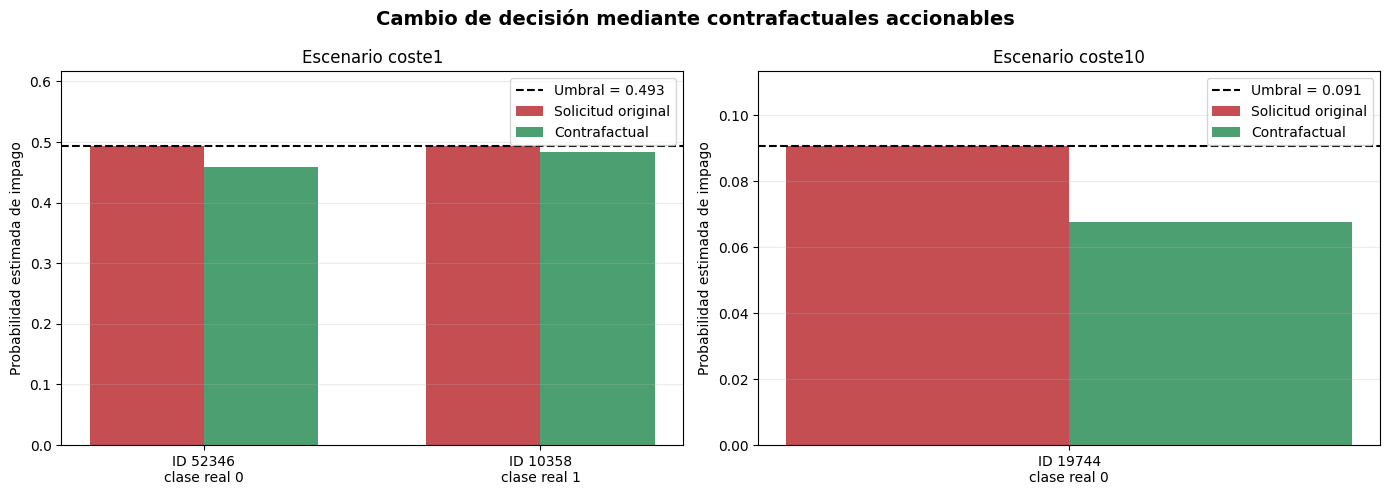

Figura guardada en: c:\Users\Fernando Dapena T\Desktop\XAI\TAREA_XAI\results\figures\contrafactuals_probabilidad_original_vs_cf.png


In [17]:
# Figura: probabilidad original frente al contrafactual válido
casos_con_cf = contrafactuals_clientes[
    contrafactuals_clientes["estado_cf"].eq("generado")
    & contrafactuals_clientes["cf_plausible"].eq(True)
].copy()

if casos_con_cf.empty:
    print("No hay contrafactuales plausibles para representar.")
else:
    escenarios = ["coste1", "coste10"]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5),
        sharey=False,
    )
    for ax, escenario in zip(axes, escenarios):
        datos = casos_con_cf[
            casos_con_cf["escenario"].eq(escenario)
        ].copy()
        if datos.empty:
            ax.set_visible(False)
            continue
        datos["etiqueta"] = datos.apply(
            lambda fila: (
                f"ID {int(fila['id_test'])}\n"
                f"clase real {int(fila['clase_real'])}"
            ),
            axis=1,
        )
        posiciones = np.arange(len(datos))
        ancho = 0.34
        ax.bar(
            posiciones - ancho / 2,
            datos["proba_impago"],
            width=ancho,
            label="Solicitud original",
            color="#C44E52",
        )
        ax.bar(
            posiciones + ancho / 2,
            datos["proba_impago_cf"],
            width=ancho,
            label="Contrafactual",
            color="#4C9F70",
        )
        umbral = float(datos["umbral"].iloc[0])
        ax.axhline(
            umbral,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"Umbral = {umbral:.3f}",
        )
        ax.set_xticks(posiciones)
        ax.set_xticklabels(datos["etiqueta"])
        ax.set_ylabel("Probabilidad estimada de impago")
        ax.set_title(f"Escenario {escenario}")
        ax.set_ylim(
            0,
            max(
                datos["proba_impago"].max() * 1.15,
                umbral * 1.25,
            ),
        )
        ax.grid(axis="y", alpha=0.25)
        ax.legend()

    fig.suptitle(
        "Cambio de decisión mediante contrafactuales accionables",
        fontsize=14,
        fontweight="bold",
    )
    fig.tight_layout()
    ruta_figura_cf = (
        ROOT
        / "results"
        / "figures"
        / "contrafactuals_probabilidad_original_vs_cf.png"
    )
    ruta_figura_cf.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        ruta_figura_cf,
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()
    print(f"Figura guardada en: {ruta_figura_cf}")

## 5. Conclusiones

Resumen de los hallazgos del analisis de contrafactuales (patrones comunes o diferencias entre
los escenarios de coste, limitaciones encontradas al generarlos) de cara a `99_ENTREGA.ipynb`.

In [21]:
# 5. Resumen cuantitativo del análisis de contrafactuales

resumen_base = contrafactuals_clientes.assign(
    cf_generado=contrafactuals_clientes["estado_cf"].eq("generado"),
    cf_plausible=(
        contrafactuals_clientes["estado_cf"].eq("generado")
        & contrafactuals_clientes["cf_plausible"].fillna(False)
    ),
)

# Resultados por escenario de coste.
resumen_escenarios = (
    resumen_base
    .groupby("escenario", as_index=False)
    .agg(
        n_casos=("id_test", "size"),
        n_cf_generados=("cf_generado", "sum"),
        n_cf_plausibles=("cf_plausible", "sum"),
        proba_original_media=("proba_impago", "mean"),
    )
)

# Resultados según proximidad al umbral.
resumen_tipo_caso = (
    resumen_base
    .groupby("tipo_caso", as_index=False)
    .agg(
        n_casos=("id_test", "size"),
        n_cf_generados=("cf_generado", "sum"),
        n_cf_plausibles=("cf_plausible", "sum"),
    )
)

display(resumen_escenarios.round(4))
display(resumen_tipo_caso)

,escenario,n_casos,n_cf_generados,n_cf_plausibles,proba_original_media
0,coste1,4,2,2,0.6843
1,coste10,4,2,1,0.4829


,tipo_caso,n_casos,n_cf_generados,n_cf_plausibles
0,borde_umbral,4,4,3
1,denegacion_fuerte,4,0,0


## Conclusiones del análisis de contrafactuales

Se analizaron **[N_TOTAL] solicitudes denegadas**, seleccionando casos de clase real 0 y 1 en los escenarios coste1 y coste10. DiCE generó una alternativa para **[N_GENERADOS] casos**, de las cuales **[N_PLAUSIBLES]** superaron todas las comprobaciones de plausibilidad. En **[N_SIN_CF] casos** no se encontró una alternativa accionable bajo las restricciones adoptadas.

### Patrones observados

Los contrafactuales se encontraron principalmente en los casos próximos al umbral. Esto es coherente, ya que una solicitud situada cerca de la frontera de decisión necesita cambios menores para obtener una predicción diferente. En las denegaciones fuertes, la probabilidad de impago está mucho más alejada del umbral y las variables accionables pueden no ser suficientes para compensar el peso de características como el historial de moras.

### Diferencias entre escenarios

En el escenario coste1 se obtuvieron **[N_COSTE1] contrafactuales plausibles**, mientras que en coste10 se obtuvieron **[N_COSTE10]**. Esta diferencia no procede de dos modelos de scoring distintos, sino de los umbrales de decisión aplicados: aproximadamente 0,4934 en coste1 y 0,0906 en coste10.

El escenario asimétrico coste10 es más conservador porque penaliza con mayor intensidad la concesión de crédito a un cliente que finalmente incurre en impago. Por ello, exige una probabilidad estimada de impago mucho menor para conceder el crédito.

### Accionabilidad y plausibilidad

La generación se restringió a cuatro variables potencialmente accionables:

- Utilización de las líneas de crédito revolving.
- Ratio de deuda.
- Ingresos mensuales.
- Número de líneas de crédito y préstamos abiertos.

Se mantuvieron fijas la edad, las personas dependientes, los indicadores de valores ausentes y el historial de moras. También se limitaron las magnitudes de los cambios para evitar explicaciones matemáticamente válidas pero poco realistas, como exigir incrementos extremos de ingresos.

Los contrafactuales plausibles redujeron la probabilidad estimada de impago en una media de **[REDUCCION_MEDIA] puntos porcentuales**. Para conseguirlo fue necesario modificar una mediana de **[MEDIANA_VARIABLES] variables accionables**.

### Limitaciones

Que DiCE no encuentre una alternativa no demuestra matemáticamente que no exista. Significa que, con el método, el tamaño de búsqueda y las restricciones utilizadas, no se encontró una combinación suficientemente próxima, favorable y plausible que invirtiera la decisión.

Relajar las restricciones podría generar más contrafactuales, pero también producir recomendaciones inalcanzables o basadas en características que el cliente no puede modificar. Por este motivo, se ha preferido registrar honestamente la ausencia de un contrafactual accionable antes que presentar una explicación poco realista.

Para los clientes de clase real 0 denegados, el análisis permite estudiar falsos positivos y ofrecer una explicación individual de una decisión que resultó excesivamente conservadora. En los clientes de clase real 1 correctamente denegados, los contrafactuales tienen principalmente valor de auditoría interna y no deben presentarse como una recomendación o garantía de aprobación.

### Conclusión general

Los contrafactuales complementan al modelo subrogado: el subrogado describe reglas generales del modelo, mientras que esta técnica muestra qué cambios concretos habrían alterado una decisión individual.

Sus resultados deben comunicarse como simulaciones del comportamiento del modelo, no como recomendaciones financieras ni como garantías de concesión.